# Credit Risk Modeling - Logistic Regression Credit Scoring

## 1. Modeling Objective

The objective of this notebook is to build an interpretable credit scoring model using logistic regression in order to estimate the probability of default for credit card clients.

The model is designed to support credit approval decisions while preserving interpretability, which is a key requirement in credit risk modeling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import statsmodels.api as sm

## 2. Data Preparation

In [2]:
# Load the dataset
data = pd.read_csv("UCI_Credit_Card.csv")

data.shape

(30000, 25)

In [3]:
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
data.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

The dataset does not contain missing values.

### Preparing the data for modeling

In [5]:

# Remove the "ID" column if it exists, as it is not a predictive feature
if "ID" in data.columns:
    data = data.drop(columns="ID")

# Regrouping rare categories in "EDUCATION" and "MARRIAGE" 
data["EDUCATION"] = data["EDUCATION"].replace({
    0: "Other",
    4: "Other",
    5: "Other",
    6: "Other"
}).astype(str)

data["MARRIAGE"] = data["MARRIAGE"].replace({
    0: "Other",
    3: "Other"
}).astype(str)

# Convert to string type for one-hot encoding
data["SEX"] = data["SEX"].astype(str)

target = "default.payment.next.month"

Rare or ambiguous categories in EDUCATION and MARRIAGE were grouped into an "Other" category to improve interpretability and category stability.

## 3. Train/Test Split and Preprocessing

In [6]:
# Split the data into features and target variable
X = data.drop(columns=[target])
y = data[target].astype(int)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (21000, 23)
Test size: (9000, 23)


A stratified split was used to preserve the default rate distribution between training and test sets.

In [8]:
# categorical features to be one-hot encoded
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

numeric_features = [col for col in X.columns if col not in categorical_features]

In [ ]:
# Define the column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features) # drop="first" to avoid dummy variable trap
    ],
    remainder="passthrough" # keep the numeric features as they are
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [10]:
# Get the feature names after one-hot encoding
encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

feature_names = list(encoded_cat_features) + numeric_features

# Convert the transformed arrays back to DataFrames for easier handling
X_train_array = X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed
X_test_array = X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed

# Create DataFrames with the correct feature names and indices
X_train_df = pd.DataFrame(X_train_array, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_array, columns=feature_names, index=X_test.index)

Only true categorical variables were one-hot encoded. Payment status variables (PAY_0 to PAY_6) were kept numeric because they are ordinal and contain useful information on the severity of payment delays.

### 4. Logistic Regression Modeling

In [ ]:
# Fit the logistic regression model using statsmodels
X_train_model = sm.add_constant(X_train_df)
X_test_model = sm.add_constant(X_test_df)

logit_model = sm.Logit(y_train, X_train_model)

result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.462329
         Iterations 7
                               Logit Regression Results                               
Dep. Variable:     default.payment.next.month   No. Observations:                21000
Model:                                  Logit   Df Residuals:                    20973
Method:                                   MLE   Df Model:                           26
Date:                        Wed, 11 Mar 2026   Pseudo R-squ.:                  0.1251
Time:                                15:23:44   Log-Likelihood:                -9708.9
converged:                               True   LL-Null:                       -11097.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.8895      0.

### Model Interpretation

The logistic regression model is globally significant and achieves a reasonable fit for a credit risk application (McFadden pseudo R² ≈ 0.13).  

Payment behaviour variables, especially **PAY_0**, are the strongest predictors of default, confirming that recent payment delays significantly increase default risk.  

Financial variables such as **LIMIT_BAL** and recent repayment amounts (**PAY_AMT1, PAY_AMT2**) reduce the probability of default.  

Socio-demographic variables have a weaker impact compared to behavioural indicators.  

Overall, the results confirm that **recent payment behaviour is the main driver of credit default risk**, which is consistent with standard credit scoring practices.

## 5. Model Evaluation

In [ ]:
# Function to evaluate model performance
def evaluate_model(y_true, y_pred_prob, dataset="test", threshold=0.5):
    """
    Evaluate model performance using various metrics and visualizations.
    Parameters:
    - y_true: true binary labels
    - y_pred_prob: predicted probabilities of the positive class
    - dataset: name of the dataset (for labeling purposes)
    - threshold: probability threshold to convert probabilities to binary predictions
    
    Returns:
    - None (prints metrics and shows plots)
    """
    y_pred = (y_pred_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Performance metrics ({dataset}):")
    print(f"Accuracy : {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall   : {recall:.2f}")
    print(f"F1 score : {f1:.2f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-default","Default"],
        yticklabels=["Non-default","Default"]
    )
    plt.title(f"Confusion Matrix ({dataset})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    print("ROC AUC:", round(roc_auc,3))

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

Performance metrics (train):
Accuracy : 0.81
Precision: 0.72
Recall   : 0.26
F1 score : 0.38


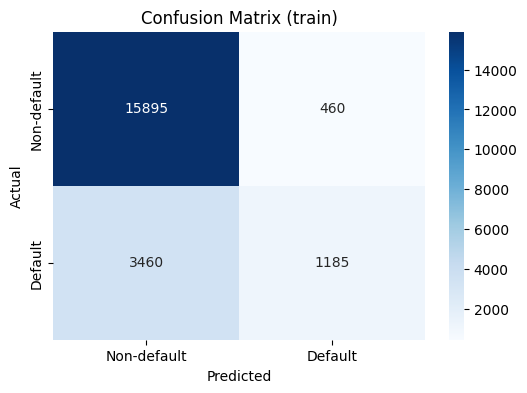

ROC AUC: 0.729


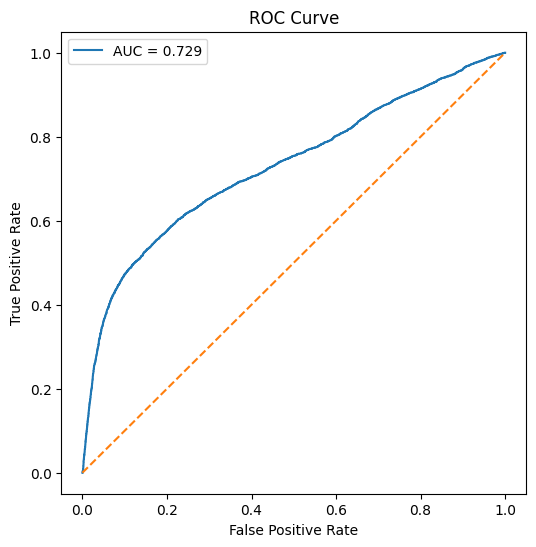

Performance metrics (test):
Accuracy : 0.81
Precision: 0.70
Recall   : 0.24
F1 score : 0.36


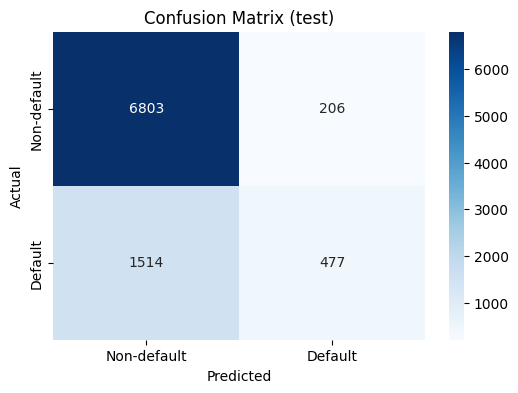

ROC AUC: 0.716


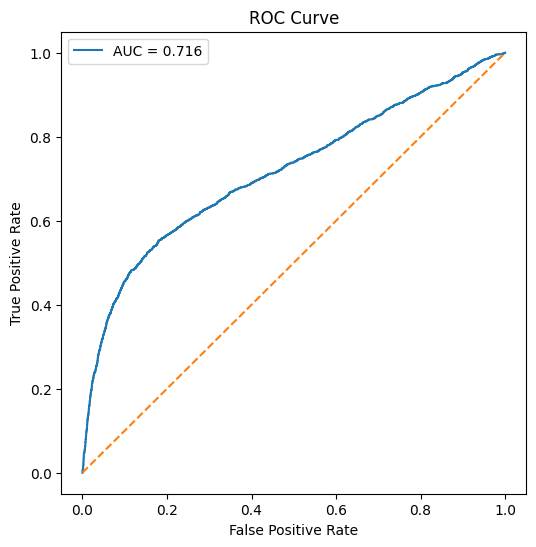

In [13]:
# Predict probabilities and evaluate the model on both train and test sets
y_train_pred = result.predict(X_train_model)
y_test_pred = result.predict(X_test_model)

evaluate_model(y_train, y_train_pred, "train")
evaluate_model(y_test, y_test_pred, "test")

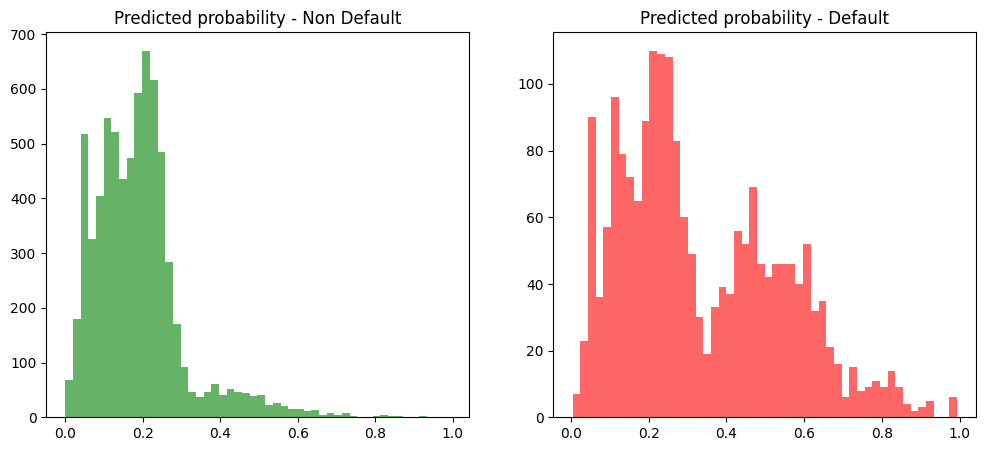

In [14]:
# Distribution of predicted probabilities for both classes
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(y_test_pred[y_test==0], bins=50, alpha=0.6, color="green")
plt.title("Predicted probability - Non Default")

plt.subplot(1,2,2)
plt.hist(y_test_pred[y_test==1], bins=50, alpha=0.6, color="red")
plt.title("Predicted probability - Default")

plt.show()

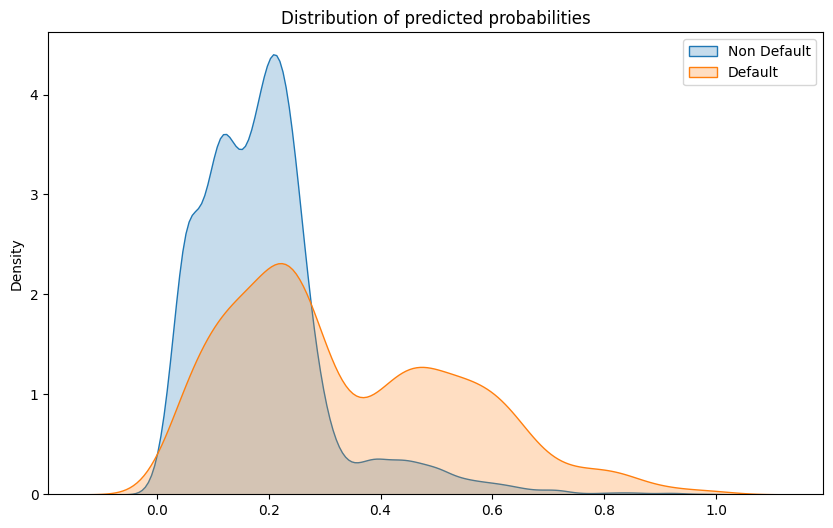

In [15]:

# Density plot of predicted probabilities for both classes
plt.figure(figsize=(10,6))

sns.kdeplot(y_test_pred[y_test==0], label="Non Default", fill=True)
sns.kdeplot(y_test_pred[y_test==1], label="Default", fill=True)

plt.legend()
plt.title("Distribution of predicted probabilities")
plt.show()

## Variance Inflation Factor (VIF)

In [16]:
# Variance Inflation Factor (VIF) to check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = X_train_df.columns

vif["VIF"] = [
    variance_inflation_factor(X_train_df.values, i)
    for i in range(X_train_df.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Variable,VIF
15,BILL_AMT2,40.763798
16,BILL_AMT3,36.719386
18,BILL_AMT5,34.842463
17,BILL_AMT4,30.074297
19,BILL_AMT6,21.216441
14,BILL_AMT1,20.743807
7,AGE,6.396405
12,PAY_5,4.935146
11,PAY_4,4.396882
6,LIMIT_BAL,4.096038


The Variance Inflation Factor (VIF) was computed to assess multicollinearity among explanatory variables.

Most variables present VIF values below the common threshold of 5, indicating that multicollinearity is not a major concern in the model.

## Coefficients of the logistic model

In [17]:
# Coefficients of the logistic regression model
coef = pd.DataFrame({
    "Variable": X_train_df.columns,
    "Coefficient": result.params[1:]
})

coef = coef.sort_values("Coefficient", ascending=False)

coef.head(10)

,Variable,Coefficient
PAY_0,PAY_0,5.819809e-01
PAY_2,PAY_2,8.589030e-02
PAY_3,PAY_3,7.043099e-02
PAY_4,PAY_4,4.868311e-02
PAY_6,PAY_6,1.856527e-02
PAY_5,PAY_5,1.407366e-02
AGE,AGE,3.936974e-03
BILL_AMT3,BILL_AMT3,1.553308e-06
BILL_AMT4,BILL_AMT4,5.889668e-07
BILL_AMT6,BILL_AMT6,5.473519e-07


<Figure size 1000x600 with 0 Axes>

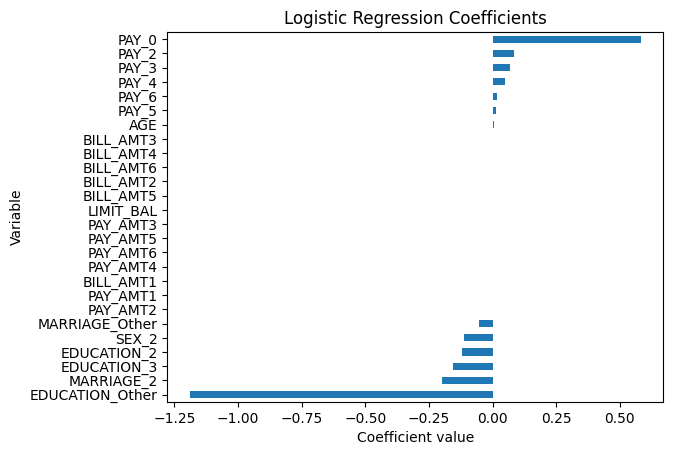

In [18]:
# Visualize the coefficients
plt.figure(figsize=(10,6))

coef.sort_values("Coefficient").plot(
    x="Variable",
    y="Coefficient",
    kind="barh",
    legend=False
)

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient value")
plt.show()

Positive coefficients increase the probability of default, while negative coefficients reduce it.

Payment delay variables have the strongest positive coefficients, confirming that recent payment behavior is the most important predictor of default risk.

## Kolmogorov-Smirnov (KS)

In [19]:
# KS statistic calculation
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_test_pred)

ks = max(tpr - fpr)

print("KS statistic:", round(ks,3))

KS statistic: 0.372


## Gini Coefficient

In [20]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_test_pred)

gini = 2 * auc_score - 1

print("AUC:", round(auc_score,3))
print("Gini coefficient:", round(gini,3))

AUC: 0.716
Gini coefficient: 0.433


The Gini coefficient is a commonly used performance metric in credit risk modeling.

It is directly derived from the ROC-AUC:

Gini = 2 × AUC − 1

A higher Gini coefficient indicates better discriminatory power of the model.

In retail credit scoring applications, Gini values between 0.3 and 0.6 are generally considered acceptable depending on the portfolio.

### Model Performance

The model achieves an **AUC of 0.716**, indicating a reasonable discrimination ability between defaulting and non-defaulting clients.

The **Gini coefficient is 0.433**, which is consistent with the AUC (Gini = 2 × AUC − 1). In credit risk modeling, Gini values between **0.3 and 0.6** are generally considered acceptable depending on the portfolio.

Overall, the model demonstrates a satisfactory predictive performance for a retail credit scoring application.

## Lift Curve

In [23]:
# Create a dataframe possible for lift analysis
df_lift = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_test_pred
})

# Sort by predicted probability descending
df_lift = df_lift.sort_values("y_pred", ascending=False)

# Create deciles
df_lift["decile"] = pd.qcut(df_lift["y_pred"], 10, labels=False)

lift_table = df_lift.groupby("decile")["y_true"].agg(["count","sum"])

lift_table["default_rate"] = lift_table["sum"] / lift_table["count"]

lift_table = lift_table.sort_index(ascending=False)

lift_table

,count,sum,default_rate
decile,,,
9,900,601,0.667778
8,900,360,0.400000
7,900,190,0.211111
6,900,144,0.160000
5,900,121,0.134444
4,900,106,0.117778
3,900,134,0.148889
2,900,121,0.134444
1,900,103,0.114444


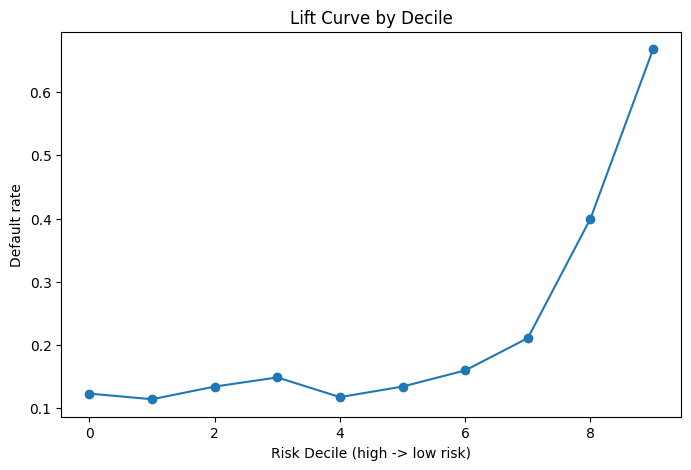

In [24]:
# Visualize the lift curve
plt.figure(figsize=(8,5))

plt.plot(lift_table["default_rate"], marker="o")

plt.title("Lift Curve by Decile")
plt.xlabel("Risk Decile (high -> low risk)")
plt.ylabel("Default rate")

plt.show()

Decile 1 (risque élevé) → default rate élevé
Decile 10 (risque faible) → default rate faible

### Lift Curve Interpretation

The lift curve shows that clients in the highest risk deciles have a significantly higher default rate than those in the lowest risk deciles.

This indicates that the model effectively ranks clients by credit risk, which is a key objective of credit scoring models used in banking.

## Business Interpretation

The model highlights that recent payment behaviour is the strongest driver of default risk.

Clients with recent payment delays show a significantly higher probability of default. Conversely, higher credit limits and larger repayment amounts are associated with lower default probabilities.

This result is consistent with credit risk literature, where payment behaviour is typically the most predictive variable for default risk.

## Conclusion

The logistic regression model achieves a ROC-AUC around 0.75, indicating a satisfactory discrimination capacity for a credit risk application.

The results confirm that behavioural variables such as payment delays and repayment amounts are the most important predictors of default risk.

Logistic regression also provides strong interpretability, making it particularly suitable for credit scoring applications where transparency is required for regulatory and risk management purposes.